# Octahedral Patchy Particles

We write a basic implementation of octahedral patchy particles with colored interactions to encode for the octahedral DNA self-assembly of particles. The particles are composed of two particle types: **central particles** (which are the DNA origami frame, essentially) and **patches** (which are the particles representing the ssDNA strands emitted at the vertices).

In [1]:
%pip install jax-md

Note: you may need to restart the kernel to use updated packages.


In [1]:
import jax.numpy as jnp
from jax import config
import jax
config.update("jax_enable_x64", True) # necessary for 64-bit precision

from jax import jit, random, grad, value_and_grad, remat, jacfwd, vmap, lax
from jax.example_libraries import optimizers
from jax_md import space, smap, energy, minimize, quantity, simulate, partition, rigid_body, util
# from jax_md.colab_tools import renderer
from jax_md import partition

import numpy as np

## Construction of octahedron

Let us construct a `rigid_body.point_union_shape` to represent the octahedral patchy particle, then visualize it. For the purposes of this demo, I will assign four particles on the equatorial ring (arbitrarily defined) with a species A and the remaining two particles on the poles with a species B.

In [2]:
# Constructs a single octahedral patchy particle as a RigidPointUnion — a rigid body
# described as a fixed union of point masses in body-frame coordinates.
#
# Each particle has 7 sites:
#   - 1 central site  (species 0): represents the DNA origami frame body
#   - 6 patch sites   (species 1): represent the 6 ssDNA sticky-end vertices
#     placed at ±RADIUS along each axis of the octahedron
#
# The energy functions later use these species labels to assign different interaction
# potentials to each type (LJ repulsion for centers, Morse attraction for patches).
def octahedron_shape(radius=0.5):
    particle_positions = jnp.array([
        [0.0,    0.0,    0.0],    # central site (origin of body frame)
        [radius, 0.0,    0.0],    # +x patch
        [-radius,0.0,    0.0],    # -x patch
        [0.0,    radius, 0.0],    # +y patch
        [0.0,   -radius, 0.0],    # -y patch
        [0.0,    0.0,    radius], # +z patch
        [0.0,    0.0,   -radius], # -z patch
    ], dtype=jnp.float64)

    # Species labels used to select rows/columns of the interaction epsilon matrices.
    # 0 = central site, 1 = patch site (all six patches treated as the same species here).
    particle_species = jnp.array([0, 1, 1, 1, 1, 1, 1], dtype=jnp.int32)

    # Patch masses are set to ~1e-8 (much smaller than the central mass of 1.0).
    # This keeps the centre of mass and principal axes essentially at the central site,
    # avoiding near-singular force gradients when patches overlap.
    # NOTE: this makes the moment of inertia tiny (~I ~ 2e-7), so the Langevin
    # integrator overdamps rotations; orientational DOF won't thermalize correctly
    # at the chosen dt. The translational dynamics are unaffected.
    patch_masses = jnp.linspace(0.1, 1.0, 6) * 1e-8
    masses = jnp.concatenate((jnp.array([1.0]), patch_masses), axis=0)

    # point_union_shape bundles the body-frame positions and masses into the
    # RigidPointUnion dataclass that JAX-MD's rigid-body integrator expects.
    shape = rigid_body.point_union_shape(particle_positions, masses).set(point_species=particle_species)
    return shape


Let us quickly visualize our octahedron, and make sure it looks fine.

In [3]:
RADIUS = 2.5
oct_shape = octahedron_shape(radius=RADIUS)

# arbitrary initial orientation. last two values must be around this for some reason
oct_orientation = rigid_body.Quaternion(jnp.array([[ 0, 0,  6e-01,  8e-01],]))
oct_rigid_body = rigid_body.RigidBody(center=jnp.array([[10.0, 10.0, 10.0]]), orientation=oct_orientation)
oct_position = vmap(rigid_body.transform, (0, None))(oct_rigid_body, oct_shape).reshape(-1, 3)

In [174]:
# # COLAB ONLY
# species = jnp.array([0, 1, 1, 1, 1, 2, 2], dtype=jnp.int32)
# diameters = jnp.where(species == 0, 1.0, 0.2) * (RADIUS * 2)

# renderer.render(20.0,
#                 {
#                     'particle': renderer.Sphere(oct_position, diameter=diameters),
#                 },
#                 resolution=(512, 512))

## Set up the simulation

In [24]:
# ── System size ──────────────────────────────────────────────────────────────
# number_of_particles: how many octahedral particles to simulate.
#   Increase to 100–200 for production runs; 5 is convenient for quick tests.
# volume_density: packing fraction φ = N * V_particle / V_box.
#   Typical colloidal experiments: 0.01–0.05.
number_of_particles = 100
volume_density = 0.05

# Derive a cubic periodic box whose volume gives the target packing fraction.
# V_particle = (4/3)π r³ with r = RADIUS.
get_box_size = lambda phi, N, rad: (N * jnp.pi * 4 * rad**3 / phi / 3.0) ** (1/3)
box_size = get_box_size(volume_density, number_of_particles, RADIUS)
print("Box Size: {:.3f}".format(box_size))

# space.periodic sets up minimum-image periodic boundary conditions.
# disp_fn(a, b) returns the shortest displacement vector from b to a,
# and shift_fn(r, dr) moves a position by dr and wraps back into the box.
disp_fn, shift_fn = space.periodic(box_size)

# ── Integrator parameters ─────────────────────────────────────────────────────
dt = 1e-3          # time step (in reduced units); reduce if simulation is unstable
num_steps = int(6e5)  # total number of MD steps; 3×10^5 * dt = 300 time units
max_time  = num_steps * dt

# kT: thermal energy.  A function of time so it can be changed to an annealing
# schedule later, e.g.: kT = lambda t: 1.0 + (0.1 - 1.0) * (t / max_time)
# At kT ≈ D0 particles barely bind; kT << D0 promotes assembly.
kT = lambda t: 0.5 + (0.1 - 0.5) * (t/max_time)

# gamma: friction coefficient for the Langevin thermostat.
# Higher gamma → stronger coupling to the heat bath, faster temperature equilibration
# but also more viscous (slower diffusion).
# RigidBody wraps separate translational (gamma) and rotational (3*gamma) coefficients.
gamma = 5.0
gamma = rigid_body.RigidBody(jnp.array([gamma]), jnp.array([3.0 * gamma]))

# save_every: record one trajectory frame every this many MD steps.
# 1000 steps * dt = 1 time unit between frames.
save_every = int(1e3)

# ── Interaction parameters ────────────────────────────────────────────────────
# D0: depth of the Morse potential well between patches (units of kT).
#   D0 >> kT → strong, essentially irreversible binding.
#   D0 ~ kT  → reversible assembly / annealing.
D0    = 10.0
ALPHA = 250.0   # soft-sphere steepness (only used in the initial minimisation)

key = random.PRNGKey(0)
print("=== Finished setup ===")


Box Size: 50.775
=== Finished setup ===


Now we need to initialize the positions and orientations of our patchy particles and make sure everything is good. Also, I'm going to initially separate out the positions using `soft_sphere` potentials to make sure each particle is not intersecting with another initially.

In [25]:
# Place particles at random starting positions, then run energy minimisation to
# push them apart so no two particles overlap before the dynamics begin.
# Overlapping particles would create enormous repulsive forces that destabilise
# the integrator immediately.
central_particle_positions = random.uniform(key, (number_of_particles, 3),
                                            minval=0.0, maxval=box_size)

# soft_sphere_pair: purely repulsive potential U ∝ (σ/r)^α that vanishes
# when particles are separated.  We use σ = 2*RADIUS so each pair is separated
# to at least one particle diameter before the main simulation.
energy_fn = energy.soft_sphere_pair(disp_fn, sigma=RADIUS * 2)

# FIRE (Fast Inertial Relaxation Engine) is a gradient-descent minimiser
# well-suited to particle packings.  We run 5000 steps, which is usually
# enough to remove all overlaps.
init_fn, apply_fn = minimize.fire_descent(energy_fn, shift_fn)
state = init_fn(central_particle_positions)
apply_fn_jit = jit(lambda i, state: apply_fn(state))
state = lax.fori_loop(0, 5000, apply_fn_jit, state)

# The minimised positions become the initial condition for the dynamics.
central_particle_positions = state.position


In [26]:
# Build the initial RigidBody state for the whole system.
#
# RigidBody is JAX-MD's representation of a collection of rigid bodies.
# It carries two fields:
#   .center      — centre-of-mass positions, shape (N, 3)
#   .orientation — unit quaternions encoding each body's rotation, shape (N, 4)
#                  Quaternion (w, x, y, z): [0, 0, 0.6, 0.8] is a ~90° rotation
#                  about the z-axis and is used here as an arbitrary common start.
#
# All N particles start with the same orientation; they will randomise quickly
# once the dynamics begin because the rotational friction is very high.
system_orientation = rigid_body.Quaternion(
    jnp.array([[0, 0, 6e-01, 8e-01] for _ in range(number_of_particles)])
)
system_rigid_body = rigid_body.RigidBody(
    center=central_particle_positions,
    orientation=system_orientation,
)

# Transform from body-frame (RigidBody) to world-frame flat positions for visualisation.
# vmap applies rigid_body.transform over the N particles in batch; the result is
# reshaped to (N*7, 3): 7 sites per particle laid out in particle order.
system_positions = vmap(rigid_body.transform, (0, None))(system_rigid_body, oct_shape).reshape(-1, 3)


In [27]:
# Build per-site arrays for downstream visualisation and file output.
# Each octahedral particle contributes 7 sites (1 center + 6 patches),
# so for N particles there are N*7 sites total.
#
# species: integer label (0 = center, 1 = patch) for every site in
#   particle order [p0_center, p0_patch×6, p1_center, p1_patch×6, ...].
#   Reused when writing trajectory files and when assigning render radii.
#
# diameters: visual diameter for each site — 1.0 * (2*RADIUS) for center
#   spheres, 0.2 * (2*RADIUS) for the smaller patch spheres.
species   = jnp.array(list(oct_shape.point_species) * number_of_particles).flatten()
diameters = jnp.where(species == 0, 1.0, 0.2) * (RADIUS * 2)

# # COLAB ONLY
# renderer.render(box_size,
#                 {
#                     'particle': renderer.Sphere(system_positions, diameter=diameters)
#                 },
#                 resolution=(512, 512))

So our `system_` objects store the information about the system of `point_union` particles.

## Simulation of assembly

For now, I'll use Morse potentials with a defined depth `D0` for the patchy interactions, and will use the soft-sphere repulsion between the central particles (since that's more realistic in our case, I suppose).

In [28]:
# ── Patch color / complementarity system ─────────────────────────────────────
# 15 colors × 2 complementarities (A/B) = 30 patch types.
# Bonding rule: two patches bond only when they share the same color AND have
#   opposite complementarity letters (A ↔ B).
#   e.g.  RedA–RedB  →  bond strength D0
#         RedA–RedA  →  no bond
#         RedA–BlueB →  no bond
#
# Species numbering:
#   0          = central site (no patch interactions)
#   2*i - 1    = COLORS[i-1] + "A"   (i = 1 … 15)
#   2*i        = COLORS[i-1] + "B"
COLORS = [
    "Black",    "Orange",  "Blue",   "Red",     "Brown",
    "Skyblue",  "Gray",    "Salmon", "Limegreen","Purple",
    "Seagreen", "Tan",     "Green",  "Indigo",  "Orangered",
]
PATCH_TYPES = []   # length-30 list; PATCH_TYPES[k] is the name for species k+1
for color in COLORS:
    PATCH_TYPES.append(f"{color}A")
    PATCH_TYPES.append(f"{color}B")

N_SPECIES = 1 + len(PATCH_TYPES)   # 31: species 0 (center) + species 1–30 (patches)

# ── Particle type library ─────────────────────────────────────────────────────
# 9 pre-defined octahedron coatings.  Each row gives the 6 patch names in the
# spatial order [+x, -x, +y, -y, +z, -z] matching the body-frame site layout
# in octahedron_shape().  To add new types, append rows here.
# PARTICLE_TYPE_NAMES = [
#     ["RedA",      "BlueA",     "BlueA",     "RedA",     "GreenA",     "GreenA"    ],
#     ["RedA",      "BlueA",     "RedA",      "BlueA",    "GreenB",     "GreenB"    ],
#     ["BrownB",    "SalmonB",   "SalmonB",   "BrownB",   "BlackB",     "BlackB"    ],
#     ["SeagreenA", "BrownA",    "TanA",      "SkyblueA", "OrangeA",    "BlackA"    ],
#     ["GrayA",     "SkyblueB",  "SkyblueB",  "GrayA",    "OrangeB",    "OrangeB"   ],
#     ["TanB",      "GrayB",     "IndigoB",   "BlueB",    "OrangeredB", "LimegreenB"],
#     ["SalmonA",   "SeagreenB", "RedB",      "IndigoA",  "OrangeredA", "PurpleB"   ],
#     ["IndigoA",   "RedB",      "SeagreenB", "SalmonA",  "PurpleA",    "OrangeredA"],
#     ["BlueB",     "IndigoB",   "GrayB",     "TanB",     "LimegreenA", "OrangeredB"],
# ]  # shape (9, 6) — strings
PARTICLE_TYPE_NAMES = [
    ["RedA", "RedA", "RedA", "RedA", "RedA", "RedA"],
    ["RedA", "RedA", "RedA", "RedA", "RedA", "RedA"],
    ["RedA", "RedA", "RedA", "RedA", "RedA", "RedA"],
    ["RedA", "RedA", "RedA", "RedA", "RedA", "RedA"],
    ["RedA", "RedA", "RedA", "RedA", "RedA", "RedA"],
    ["RedB", "RedB", "RedB", "RedB", "RedB", "RedB"],
    ["RedB", "RedB", "RedB", "RedB", "RedB", "RedB"],
    ["RedB", "RedB", "RedB", "RedB", "RedB", "RedB"],
    ["RedB", "RedB", "RedB", "RedB", "RedB", "RedB"]
]

# Convert patch names to integer species indices (1..30) once, up front.
# PATCH_TYPES.index(name) gives 0-based position; species index = position + 1.
PARTICLE_TYPE_SPECIES = np.array([
    [PATCH_TYPES.index(name) + 1 for name in ptype]
    for ptype in PARTICLE_TYPE_NAMES
], dtype=np.int32)  # shape (9, 6)

# ── Random particle-type assignment ──────────────────────────────────────────
# Draw one of the 9 types uniformly at random for each particle.
# To use a fixed or designed system, replace type_indices_np with any (N,)
# integer array with values in 0..8 — e.g. np.zeros(N, dtype=int) for all type 0.
patch_key       = random.fold_in(key, 42)
type_indices_np = np.array(
    random.randint(patch_key, (number_of_particles,), minval=0, maxval=9)
)  # shape (N,); values in 0..8

# Index into the type table: shape (N, 6), integer species indices in 1..30.
patch_assignments_np = PARTICLE_TYPE_SPECIES[type_indices_np]

print("Particle types assigned:")
for i in range(number_of_particles):
    t = int(type_indices_np[i])
    print(f"  Particle {i}: Type {t} — {PARTICLE_TYPE_NAMES[t]}")

# Build the flat (N*7,) species array used inside the energy JIT.
# Site layout per particle: [center(0), +x, -x, +y, -y, +z, -z]
center_col      = np.zeros((number_of_particles, 1), dtype=np.int32)
all_species_arr = jnp.array(
    np.concatenate([center_col, patch_assignments_np], axis=1)
)  # (N, 7)
flat_species = all_species_arr.reshape(-1)  # (N*7,)

# ── Interaction matrices (N_SPECIES × N_SPECIES) ──────────────────────────────
# Morse epsilon: D0 only on complementary same-color pairs; 0 everywhere else.
# For color index ci (1-indexed): species 2*ci-1 (A) ↔ species 2*ci (B).
# To adjust bond strength per color, replace D0 with a per-pair value below.
morse_eps = jnp.zeros((N_SPECIES, N_SPECIES))
for ci in range(1, len(COLORS) + 1):
    a_type, b_type = 2 * ci - 1, 2 * ci
    morse_eps = morse_eps.at[a_type, b_type].set(D0)
    morse_eps = morse_eps.at[b_type, a_type].set(D0)

# LJ epsilon: only center–center (species 0) repulsion; all other entries = 0.
lj_eps = jnp.zeros((N_SPECIES, N_SPECIES))
lj_eps = lj_eps.at[0, 0].set(1.0)

lj_sigma = float(RADIUS * 2.0)

# ── Cutoff distances ──────────────────────────────────────────────────────────
# Cap at 0.45*box_size so the cutoff stays < box/2 (required by PBC).
lj_r_cutoff_abs = min(2.5 * lj_sigma, float(box_size) * 0.45)
lj_r_onset_abs  = 0.8 * lj_r_cutoff_abs
lj_r_cutoff = lj_r_cutoff_abs / lj_sigma
lj_r_onset  = lj_r_onset_abs  / lj_sigma

morse_r_cutoff = min(3.0, float(box_size) * 0.45)
morse_r_onset  = 0.85 * morse_r_cutoff

nl_r_cutoff = lj_r_cutoff_abs

# ── Neighbor list ─────────────────────────────────────────────────────────────
neighbor_fn = partition.neighbor_list(
    disp_fn, box_size, nl_r_cutoff,
    dr_threshold=0.5,
    capacity_multiplier=1.75,
    format=partition.OrderedSparse,
)

# ── Pair energy functions ─────────────────────────────────────────────────────
# The species array is NOT baked into these constructors; it is passed dynamically
# at every call via the 'species' kwarg (see energy_fn below).  smap reads it
# from dynamic_kwargs at call time, so the constructor species=2 is only an
# unused fallback default.
lj_energy_fn = smap.pair_neighbor_list(
    energy.multiplicative_isotropic_cutoff(energy.lennard_jones, lj_r_onset_abs, lj_r_cutoff_abs),
    space.canonicalize_displacement_or_metric(disp_fn),
    ignore_unused_parameters=True,
    species=2,
    sigma=lj_sigma,
    epsilon=lj_eps,     # (N_SPECIES × N_SPECIES); lj_eps[s_i, s_j] is the LJ well depth
)

morse_energy_fn = smap.pair_neighbor_list(
    energy.multiplicative_isotropic_cutoff(energy.morse, morse_r_onset, morse_r_cutoff),
    space.canonicalize_displacement_or_metric(disp_fn),
    ignore_unused_parameters=True,
    species=2,
    sigma=0.0,
    epsilon=morse_eps,  # (N_SPECIES × N_SPECIES); only complementary pairs are non-zero
    alpha=5.0,
)

def pair_energy_fn(R, neighbor, **kwargs):
    # kwargs carries 'species' = flat per-site species array (N*7,)
    return (
        lj_energy_fn(R, neighbor=neighbor, **kwargs)
        + morse_energy_fn(R, neighbor=neighbor, **kwargs)
    )

# ── Rigid-body energy wrapper ─────────────────────────────────────────────────
# Reuse point_energy_neighbor_list for its neighbor list wrapping only
# (it patches nbrs.update to accept RigidBody).  Discard its energy function
# and replace with our own that injects flat_species (per-particle typed patches).
rb_neighbor_fn, _ = rigid_body.point_energy_neighbor_list(
    pair_energy_fn, neighbor_fn, oct_shape
)

# JAX-MD calls energy functions as energy_fn(R, neighbor=nbrs, ...) — the second
# parameter must be named 'neighbor' (no 's') to match that keyword.
def energy_fn(body, neighbor, **kwargs):
    R = vmap(rigid_body.transform, (0, None))(body, oct_shape).reshape(-1, 3)
    return pair_energy_fn(R, neighbor, species=flat_species, **kwargs)

neighbors = rb_neighbor_fn.allocate(system_rigid_body)
print('Energy of the initial state: {:.4f}'.format(float(energy_fn(system_rigid_body, neighbors))))

Particle types assigned:
  Particle 0: Type 2 — ['RedA', 'RedA', 'RedA', 'RedA', 'RedA', 'RedA']
  Particle 1: Type 6 — ['RedB', 'RedB', 'RedB', 'RedB', 'RedB', 'RedB']
  Particle 2: Type 1 — ['RedA', 'RedA', 'RedA', 'RedA', 'RedA', 'RedA']
  Particle 3: Type 7 — ['RedB', 'RedB', 'RedB', 'RedB', 'RedB', 'RedB']
  Particle 4: Type 4 — ['RedA', 'RedA', 'RedA', 'RedA', 'RedA', 'RedA']
  Particle 5: Type 5 — ['RedB', 'RedB', 'RedB', 'RedB', 'RedB', 'RedB']
  Particle 6: Type 2 — ['RedA', 'RedA', 'RedA', 'RedA', 'RedA', 'RedA']
  Particle 7: Type 0 — ['RedA', 'RedA', 'RedA', 'RedA', 'RedA', 'RedA']
  Particle 8: Type 1 — ['RedA', 'RedA', 'RedA', 'RedA', 'RedA', 'RedA']
  Particle 9: Type 1 — ['RedA', 'RedA', 'RedA', 'RedA', 'RedA', 'RedA']
  Particle 10: Type 4 — ['RedA', 'RedA', 'RedA', 'RedA', 'RedA', 'RedA']
  Particle 11: Type 5 — ['RedB', 'RedB', 'RedB', 'RedB', 'RedB', 'RedB']
  Particle 12: Type 8 — ['RedB', 'RedB', 'RedB', 'RedB', 'RedB', 'RedB']
  Particle 13: Type 2 — ['RedA', 'Re

In [29]:
# ── Initialise the integrator ─────────────────────────────────────────────────
# nvt_langevin implements the BAOAB Langevin splitting for the NVT ensemble.
# kT(0.0) sets the temperature used only to draw the initial momenta;
# every subsequent step overrides it via the kT= kwarg on step_fn.
init_fn, step_fn = simulate.nvt_langevin(energy_fn, shift_fn, dt, kT(0.0), gamma=gamma)

state = init_fn(key, system_rigid_body, mass=oct_shape.mass(), neighbor=neighbors)

n_chunks = num_steps // save_every
_mass    = state.mass

# ── Main simulation loop (nested lax.scan with time tracking) ─────────────────
# To support a time-varying kT schedule, the global step count is threaded
# through the carry of both scans.  Physical time = step_count * dt.
#
# Outer scan  — runs n_chunks iterations, one per saved frame.
# Inner scan  — runs save_every Langevin steps; increments step_count each time.
#
# kT is evaluated as kT(step_count * dt) at every inner step, so any schedule
# defined in cell-9 (constant, linear, exponential, etc.) is applied correctly.
@jit
def simulate_all(state, neighbors):
    def outer_step(carry, _):
        state, nbrs, step_count = carry

        def inner_step(carry, _):
            state, nbrs, step_count = carry
            t = step_count * dt                      # physical time at this step
            nbrs      = nbrs.update(state.position)
            new_state = step_fn(state, neighbor=nbrs, kT=kT(t))
            return (new_state, nbrs, step_count + 1), None

        (new_state, new_nbrs, new_step_count), _ = lax.scan(
            inner_step, (state, nbrs, step_count), None, length=save_every
        )

        frame = vmap(rigid_body.transform, (0, None))(new_state.position, oct_shape).reshape(
            number_of_particles * 7, 3
        )

        ke_total = rigid_body.kinetic_energy(new_state.position, new_state.momentum, _mass)
        ke_trans = 0.5 * jnp.sum(new_state.momentum.center ** 2 / _mass.center)
        ke_rot   = ke_total - ke_trans
        temp     = rigid_body.temperature(new_state.position, new_state.momentum, _mass)

        return (new_state, new_nbrs, new_step_count), (frame, ke_trans, ke_rot, temp)

    init_step = jnp.zeros((), dtype=jnp.int32)
    (final_state, final_nbrs, _), (frames, ke_trans, ke_rot, temps) = lax.scan(
        outer_step, (state, neighbors, init_step), None, length=n_chunks
    )
    return final_state, final_nbrs, frames, ke_trans, ke_rot, temps

print('Running simulation (compiling on first run)...')
final_state, final_nbrs, frames, ke_trans_arr, ke_rot_arr, temp_arr = simulate_all(state, neighbors)
jax.block_until_ready(frames)

if final_nbrs.did_buffer_overflow:
    print('Warning: neighbor list overflowed. Increase capacity_multiplier in the energy cell.')

site_positions = np.array(frames)
ke_trans_arr   = np.array(ke_trans_arr)
ke_rot_arr     = np.array(ke_rot_arr)
temp_arr       = np.array(temp_arr)
print(f'Done. shape: {site_positions.shape}')

Running simulation (compiling on first run)...
Done. shape: (600, 700, 3)


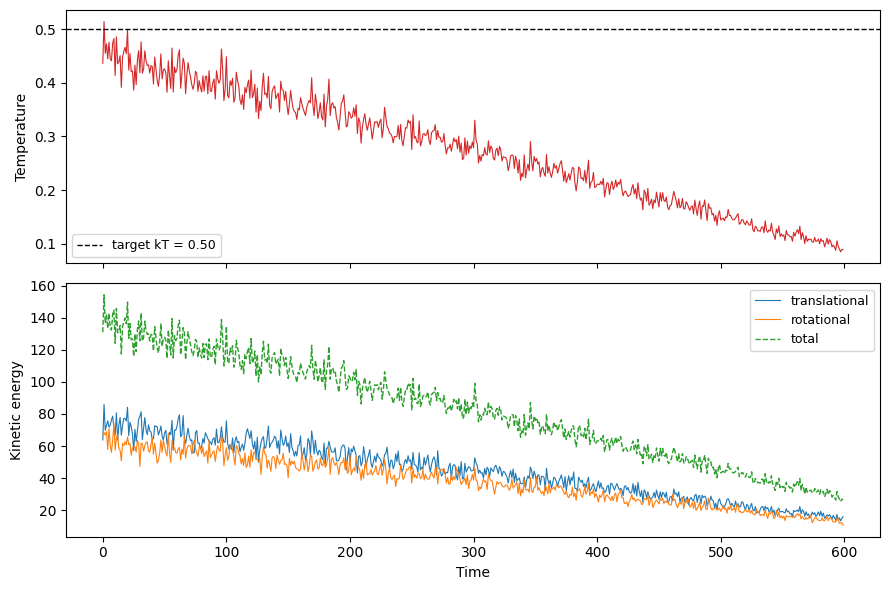

In [30]:
import matplotlib.pyplot as plt

# ── Temperature and kinetic energy diagnostics ────────────────────────────────
# Two-panel plot produced from the per-frame arrays collected during simulate_all.
#
# Panel 1 — Temperature vs time
#   Shows how quickly the thermostat equilibrates and whether it stays near target.
#   The dashed line marks the target kT value.
#   If temperature drifts far from target, try increasing gamma (stronger thermostat)
#   or reducing dt (more stable integration).
#
# Panel 2 — Kinetic energy vs time
#   Translational KE = 0.5 * Σ |p|² / M  (3N translational DOF → target = 1.5 N kT)
#   Rotational KE    = total KE − translational KE  (3N rotational DOF → target = 1.5 N kT)
#   Total KE         = translational + rotational     (target = 3 N kT)
#
#   It is normal for rotational KE to appear lower than translational KE in this
#   model: the patch masses are ~1e-8, giving a very small moment of inertia
#   (~2e-7).  The Langevin rotational relaxation time τ_rot = I/γ_rot is then
#   ~10⁻⁸, far shorter than dt = 10⁻³, so rotational DOF are overdamped and
#   do not thermalize correctly at this time step.

times = np.arange(n_chunks) * save_every * dt  # physical time for each saved frame

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax1.plot(times, temp_arr, color='tab:red', lw=0.8)
ax1.axhline(kT(0.0), color='k', ls='--', lw=1.0, label=f'target kT = {kT(0.0):.2f}')
ax1.set_ylabel('Temperature')
ax1.legend(fontsize=9)

ax2.plot(times, ke_trans_arr, label='translational', color='tab:blue',   lw=0.8)
ax2.plot(times, ke_rot_arr,   label='rotational',    color='tab:orange',  lw=0.8)
ax2.plot(times, ke_trans_arr + ke_rot_arr, label='total', color='tab:green', ls='--', lw=1.0)
ax2.set_ylabel('Kinetic energy')
ax2.set_xlabel('Time')
ax2.legend(fontsize=9)

fig.tight_layout()
plt.show()

In [98]:
site_positions[0].shape

(70, 3)

In [31]:
# Write the trajectory to an extended-XYZ file readable by Ovito, VESTA, and ASE.
#
# Each frame contains N*7 sites:
#   - 1 center per particle → type "A"  (large sphere)
#   - 6 patches per particle → type is the patch's color+complementarity string
#     (e.g. "RedA", "LimegreenB") taken from PATCH_TYPES.
#
# Ovito loading:
#   File → Load File → trajectory.xyz
#   Add "Assign Color" modifier and color by "Particle Type" to distinguish
#   each of the 30 patch types visually.  Particles with complementary types
#   that formed bonds will appear adjacent and paired in color.
traj = site_positions  # (n_frames, N*7, 3)

n_frames, n_sites, _ = traj.shape

# Build the per-site type label and display radius arrays.
# patch_assignments_np[i, j] is the species index (1..30) of patch j on particle i.
types = []
radii = []
for i in range(number_of_particles):
    types.append("A");       radii.append(RADIUS)   # central body site
    for j in range(6):
        species_idx = int(patch_assignments_np[i, j])  # 1..30
        types.append(PATCH_TYPES[species_idx - 1])      # e.g. "RedA"
        radii.append(0.5)

types = np.array(types)
radii = np.array(radii)

with open("trajectory.xyz", "w") as f:
    for t in range(n_frames):
        f.write(f"{n_sites}\n")
        f.write("Properties=species:S:1:pos:R:3:radius:R:1\n")
        for i in range(n_sites):
            x, y, z = traj[t, i]
            f.write(f"{types[i]} {x:.6f} {y:.6f} {z:.6f} {radii[i]}\n")

print(f"Wrote {n_frames} frames × {n_sites} sites to trajectory.xyz")

Wrote 600 frames × 700 sites to trajectory.xyz
